In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import seaborn as sns
import fastf1 as f1
from fastf1 import plotting
from ing_theme_matplotlib import mpl_style
import mplcyberpunk

In [2]:
def convert_to_normal(time):
    if pd.isna(time):
        return time

    time_str = str(time)
    parts = time_str.split()

    days = int(parts[0])
    minutes, seconds_with_microseconds = parts[2].split(":")[1:]
    seconds, microseconds = seconds_with_microseconds.split(".")

    minutes = int(minutes)
    seconds = int(seconds)
    microseconds = int(microseconds)

    total_microseconds = (
        days * 86400000000 + minutes * 60000000 + seconds * 1000000 + microseconds
    )

    minutes, remaining_microseconds = divmod(total_microseconds, 60000000)
    seconds, microseconds = divmod(remaining_microseconds, 1000000)

    normal_time = f"{minutes:02d}:{seconds:02d}.{microseconds:06d}"
    return normal_time

In [3]:
test = f1.get_testing_session(2026,1,2)
test.load()

req         WARNING 	DEFAULT CACHE ENABLED! (663.0 MB) /home/hexa/.cache/fastf1
core           INFO 	Loading data for Pre-Season Testing - Practice 2 [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '1'
core        WARNING 	No lap data for driver 3
core        WARNING 	Fixed incorrect tyre stint information for driver '5'
core        WARNING 	Fixed incorrect tyre stint information for driver '6'
core        WARNING 	Fixed incorrect tyre stint information for driver '14'
core        WARNING 	Fixed incorrect tyre stint information for driver '16'
core        

In [4]:
test.session_info

{'Meeting': {'Key': 1304,
  'Name': 'Pre-Season Testing',
  'OfficialName': 'FORMULA 1 ARAMCO PRE-SEASON TESTING 1 2026',
  'Location': 'Bahrain',
  'Number': 1,
  'Country': {'Key': 36, 'Code': 'BRN', 'Name': 'Bahrain'},
  'Circuit': {'Key': 63, 'ShortName': 'Sakhir'}},
 'SessionStatus': 'Inactive',
 'ArchiveStatus': {'Status': 'Generating'},
 'Key': 11466,
 'Type': 'Practice',
 'Number': 2,
 'Name': 'Day 2',
 'StartDate': datetime.datetime(2026, 2, 12, 10, 0),
 'EndDate': datetime.datetime(2026, 2, 12, 19, 0),
 'GmtOffset': datetime.timedelta(seconds=10800),
 'Path': '2026/2026-02-13_Pre-Season_Testing/2026-02-12_Day_2/'}

In [5]:
test.results.loc[
    :, ["Abbreviation", "TeamName", "GridPosition", "Position", "Time", "Status"]
]

,Abbreviation,TeamName,GridPosition,Position,Time,Status
1,NOR,McLaren,NaN,NaN,NaT,
3,VER,Red Bull Racing,NaN,NaN,NaT,
5,BOR,Audi,NaN,NaN,NaT,
6,HAD,Red Bull Racing,NaN,NaN,NaT,
10,GAS,Alpine,NaN,NaN,NaT,
11,PER,Cadillac,NaN,NaN,NaT,
12,ANT,Mercedes,NaN,NaN,NaT,
14,ALO,Aston Martin,NaN,NaN,NaT,
16,LEC,Ferrari,NaN,NaN,NaT,
18,STR,Aston Martin,NaN,NaN,NaT,


In [21]:
test_laps = test.laps
test_laps

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 00:15:31.642000,NOR,1,NaT,1.0,1.0,0 days 00:13:09.503000,0 days 00:15:29.477000,NaT,0 days 00:01:03.044000,...,False,McLaren,0 days 00:13:09.503000,2026-02-12 07:00:16.983,671,NaN,False,,False,False
1,0 days 00:29:10.400000,NOR,1,NaT,2.0,2.0,0 days 00:27:14.649000,0 days 00:29:08.555000,NaT,0 days 00:00:50.363000,...,False,McLaren,0 days 00:27:14.649000,2026-02-12 07:14:22.129,1,NaN,False,,False,False
2,0 days 01:04:42.744000,NOR,1,NaT,3.0,3.0,0 days 01:02:20.490000,NaT,NaT,0 days 00:00:50.158000,...,True,McLaren,0 days 00:29:10.400000,2026-02-12 07:16:17.880,1,NaN,False,,False,False
3,0 days 01:06:18.931000,NOR,1,0 days 00:01:36.187000,4.0,3.0,NaT,NaT,0 days 00:00:30.695000,0 days 00:00:42.295000,...,True,McLaren,0 days 01:04:42.744000,2026-02-12 07:51:50.224,1,NaN,False,,False,True
4,0 days 01:08:27.379000,NOR,1,0 days 00:02:08.448000,5.0,3.0,NaT,0 days 01:08:25.584000,0 days 00:00:43.094000,0 days 00:00:53.085000,...,True,McLaren,0 days 01:06:18.931000,2026-02-12 07:53:26.411,1,NaN,False,,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1058,0 days 08:57:19.573000,BEA,87,NaT,113.0,25.0,0 days 08:54:59.102000,0 days 08:57:17.571000,NaT,0 days 00:00:45.593000,...,True,Haas F1 Team,0 days 08:50:10.294000,2026-02-12 15:37:17.774,1,NaN,False,,False,False
1059,0 days 08:59:53.392000,BEA,87,NaT,114.0,26.0,0 days 08:57:38.292000,0 days 08:59:51.970000,0 days 00:01:22.251000,0 days 00:00:44.554000,...,False,Haas F1 Team,0 days 08:57:19.573000,2026-02-12 15:44:27.053,1,NaN,False,,False,False
1060,0 days 09:02:31.156000,BEA,87,NaT,115.0,27.0,0 days 09:00:12.073000,NaT,0 days 00:01:22.330000,0 days 00:00:50.905000,...,False,Haas F1 Team,0 days 08:59:53.392000,2026-02-12 15:47:00.872,1,NaN,False,,False,False
1061,0 days 09:04:18.886000,BEA,87,0 days 00:01:47.730000,116.0,27.0,NaT,NaT,0 days 00:00:30.916000,0 days 00:00:44.762000,...,False,Haas F1 Team,0 days 09:02:31.156000,2026-02-12 15:49:38.636,16,NaN,False,,False,False


In [9]:
lec_test_laps = test.laps.pick_driver("LEC")
lec_test_lap_time = lec_test_laps["LapTime"]
lec_test_sec1 = lec_test_laps["Sector1Time"]
lec_test_sec2 = lec_test_laps["Sector2Time"]
lec_test_sec3 = lec_test_laps["Sector3Time"]
lec_test_laps.loc[:,["LapTime","Sector1Time","Sector2Time","Sector3Time","SpeedI1","SpeedI2","SpeedFL","SpeedST"]].head()

/home/hexa/Coding/F1-data-analysis/venv/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


,LapTime,Sector1Time,Sector2Time,Sector3Time,SpeedI1,SpeedI2,SpeedFL,SpeedST
471,NaT,NaT,0 days 00:01:09.550000,0 days 00:00:35.430000,181.0,64.0,263.0,66.0
472,0 days 00:01:57.509000,0 days 00:00:39.887000,0 days 00:00:50.534000,0 days 00:00:27.088000,180.0,209.0,248.0,218.0
473,0 days 00:01:47.597000,0 days 00:00:34.949000,0 days 00:00:46.597000,0 days 00:00:26.051000,215.0,224.0,248.0,249.0
474,0 days 00:01:54.833000,0 days 00:00:39.805000,0 days 00:00:49.218000,0 days 00:00:25.810000,103.0,224.0,248.0,244.0
475,NaT,0 days 00:00:46.547000,0 days 00:00:53.841000,NaT,186.0,160.0,NaN,249.0


In [10]:
fastest_lap_lec_test = lec_test_laps.pick_fastest()
tele_lec_test = fastest_lap_lec_test.get_telemetry().add_distance()
speed_lec_test = tele_lec_test.Speed
tele_lec_test.loc[:, ["Speed", "nGear", "RPM"]]

,Speed,nGear,RPM
2,299.660713,7,11090.968081
3,301.517856,7,10726.596653
4,302.000000,8,10632.000000
5,304.912502,8,10772.770949
6,305.000000,8,10777.000000
...,...,...,...
701,286.000000,7,11393.000000
702,286.000000,7,11384.333376
703,286.000000,7,11347.666667
704,286.000000,7,11333.000000


In [11]:
lan_test_laps = test.laps.pick_driver("NOR")
lan_test_lap_time = lan_test_laps["LapTime"]
lan_test_sec1 = lan_test_laps["Sector1Time"]
lan_test_sec2 = lan_test_laps["Sector2Time"]
lan_test_sec3 = lan_test_laps["Sector3Time"]
lan_test_laps.loc[:,["LapTime","Sector1Time","Sector2Time","Sector3Time","SpeedI1","SpeedI2","SpeedFL","SpeedST"]].head()

/home/hexa/Coding/F1-data-analysis/venv/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


,LapTime,Sector1Time,Sector2Time,Sector3Time,SpeedI1,SpeedI2,SpeedFL,SpeedST
0,NaT,NaT,0 days 00:01:03.044000,0 days 00:00:33.486000,165.0,140.0,NaN,109.0
1,NaT,NaT,0 days 00:00:50.363000,0 days 00:00:29.180000,225.0,198.0,NaN,109.0
2,NaT,NaT,0 days 00:00:50.158000,0 days 00:00:27.910000,210.0,186.0,285.0,178.0
3,0 days 00:01:36.187000,0 days 00:00:30.695000,0 days 00:00:42.295000,0 days 00:00:23.197000,233.0,237.0,288.0,304.0
4,0 days 00:02:08.448000,0 days 00:00:43.094000,0 days 00:00:53.085000,0 days 00:00:32.269000,163.0,170.0,NaN,178.0


In [12]:
fastest_lap_lan_test = lan_test_laps.pick_fastest()
tele_lan_test = fastest_lap_lan_test.get_telemetry().add_distance()
speed_lan_test = tele_lan_test.Speed
tele_lan_test.loc[:, ["Speed", "nGear", "RPM"]]

,Speed,nGear,RPM
2,300.900000,8,11018.000000
3,302.000000,8,11051.000000
4,303.642858,8,11148.750054
5,304.000000,8,11170.000000
6,307.000000,8,11216.000000
...,...,...,...
684,284.000000,7,10451.000000
685,284.363636,7,10440.454545
686,285.636364,7,10403.545455
687,286.000000,8,10393.000000


In [13]:
rus_test_laps = test.laps.pick_driver("RUS")
fastest_lap_rus_test = rus_test_laps.pick_fastest().LapTime
rus_test_lap_time = rus_test_laps["LapTime"]
rus_test_sec1 = rus_test_laps["Sector1Time"]
rus_test_sec2 = rus_test_laps["Sector2Time"]
rus_test_sec3 = rus_test_laps["Sector3Time"]
print("Fastest Lap:", convert_to_normal(fastest_lap_rus_test), "which was in Lap number" ,rus_test_laps.pick_fastest().LapNumber)
rus_test_laps.loc[:,["LapTime","Sector1Time","Sector2Time","Sector3Time","SpeedI1","SpeedI2","SpeedFL","SpeedST"]].head()

Fastest Lap: 01:36.458000 which was in Lap number 6.0


/home/hexa/Coding/F1-data-analysis/venv/lib/python3.12/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


,LapTime,Sector1Time,Sector2Time,Sector3Time,SpeedI1,SpeedI2,SpeedFL,SpeedST
858,NaT,NaT,0 days 00:00:45.234000,0 days 00:00:24.664000,219.0,230.0,300.0,194.0
859,0 days 00:01:41.379000,0 days 00:00:31.802000,0 days 00:00:44.748000,0 days 00:00:24.829000,223.0,233.0,299.0,300.0
860,0 days 00:01:41.195000,0 days 00:00:31.714000,0 days 00:00:44.750000,0 days 00:00:24.731000,220.0,232.0,299.0,301.0
861,0 days 00:01:49.139000,0 days 00:00:31.718000,0 days 00:00:46.909000,0 days 00:00:30.512000,221.0,230.0,NaN,299.0
862,NaT,NaT,0 days 00:01:13.407000,0 days 00:00:26.178000,216.0,209.0,274.0,171.0


In [14]:
fastest_lap_rus_test = rus_test_laps.pick_fastest()
tele_rus_test = fastest_lap_rus_test.get_telemetry().add_distance()
speed_rus_test = tele_rus_test.Speed
tele_rus_test.loc[:, ["Speed", "nGear", "RPM"]]

,Speed,nGear,RPM
2,282.275003,7,10949.500134
3,284.000000,7,11030.000000
4,286.000000,7,11030.000000
5,286.345001,7,11052.425062
6,289.000000,7,11225.000000
...,...,...,...
720,276.000000,7,10704.000000
721,276.000000,7,10723.193783
722,276.000000,7,10785.443783
723,276.000000,7,10787.000000


In [15]:
driver1_sectors = pd.DataFrame(
    {
         "Driver": ["Max Verstappen"] * len(lec_test_sec1),
        "Sector1Time": lec_test_sec1,
        "Sector2Time": lec_test_sec2,
        "Sector3Time": lec_test_sec3,
        "Lap Time": lec_test_lap_time,
    }
)


driver2_sectors = pd.DataFrame(
    {
         "Driver": ["Oscar Piastri"] * len(lan_test_sec1),
        "Sector1Time": lan_test_sec1,
        "Sector2Time": lan_test_sec2,
        "Sector3Time": lan_test_sec3,
        "Lap Time": lan_test_lap_time,
    }
)


driver3_sectors = pd.DataFrame(
    {
         "Driver": ["George Russell"] * len(rus_test_sec1),
        "Sector1Time": rus_test_sec1,
        "Sector2Time": rus_test_sec2,
        "Sector3Time": rus_test_sec3,
        "Lap Time": rus_test_lap_time,
    }
)




all_drivers_sectors = pd.concat(
    [driver1_sectors, driver2_sectors, driver3_sectors],
    ignore_index=True,
)
all_drivers_sectors.sort_values(
    by=["Sector1Time", "Sector2Time", "Sector3Time"], ascending=True
)
all_drivers_sectors.dropna()

,Driver,Sector1Time,Sector2Time,Sector3Time,Lap Time
1,Max Verstappen,0 days 00:00:39.887000,0 days 00:00:50.534000,0 days 00:00:27.088000,0 days 00:01:57.509000
2,Max Verstappen,0 days 00:00:34.949000,0 days 00:00:46.597000,0 days 00:00:26.051000,0 days 00:01:47.597000
3,Max Verstappen,0 days 00:00:39.805000,0 days 00:00:49.218000,0 days 00:00:25.810000,0 days 00:01:54.833000
6,Max Verstappen,0 days 00:00:33.361000,0 days 00:00:45.346000,0 days 00:00:24.684000,0 days 00:01:43.391000
7,Max Verstappen,0 days 00:00:31.899000,0 days 00:00:44.432000,0 days 00:00:24.120000,0 days 00:01:40.451000
...,...,...,...,...,...
259,George Russell,0 days 00:00:30.848000,0 days 00:00:43.417000,0 days 00:00:24.050000,0 days 00:01:38.315000
260,George Russell,0 days 00:00:30.812000,0 days 00:00:43.419000,0 days 00:00:23.952000,0 days 00:01:38.183000
261,George Russell,0 days 00:00:30.730000,0 days 00:00:43.418000,0 days 00:00:23.972000,0 days 00:01:38.120000
262,George Russell,0 days 00:00:30.828000,0 days 00:00:43.341000,0 days 00:00:24.013000,0 days 00:01:38.182000


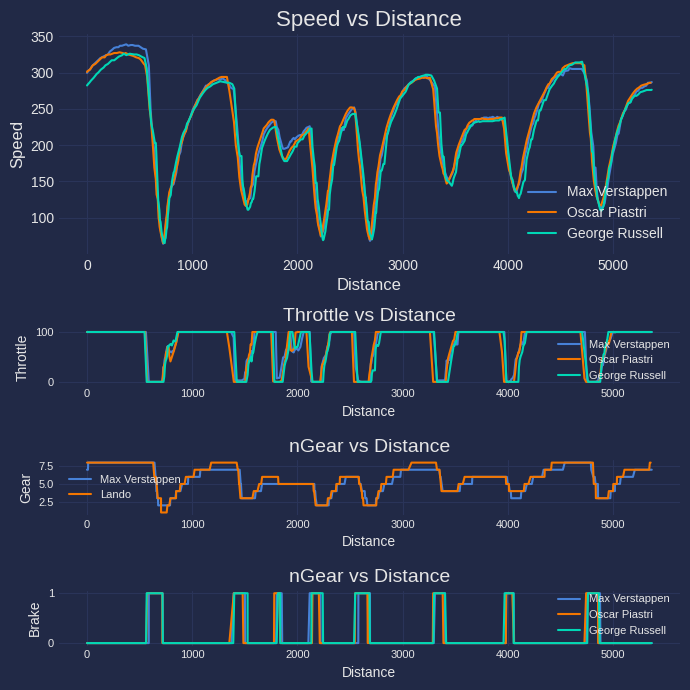

In [17]:
def hex_to_rgb(hex_color):
    hex_color = hex_color.lstrip("#")
    r, g, b = [int(hex_color[i : i + 2], 16) for i in (0, 2, 4)]
    return (r / 255, g / 255, b / 255)


def get_driver_color(driver_abbreviation):
    driver = test.get_driver(driver_abbreviation)
    team_color = driver.TeamColor
    return hex_to_rgb(team_color)


plt.style.use("cyberpunk")

fig, ax = plt.subplots(4, 1, figsize=(7, 7), gridspec_kw={"height_ratios": [4, 1, 1, 1]})

ax[0].plot(
    tele_lec_test.Distance, tele_lec_test.Speed, label="Max Verstappen", color=get_driver_color("VER")
)
ax[0].plot(
    tele_lan_test.Distance, tele_lan_test.Speed, label="Oscar Piastri", color=get_driver_color("PIA")
)
ax[0].plot(
    tele_rus_test.Distance, tele_rus_test.Speed, label="George Russell", color=get_driver_color("RUS")
)

ax[0].set_title("Speed vs Distance", fontsize=16)
ax[0].set_xlabel("Distance", fontsize=12)
ax[0].set_ylabel("Speed", fontsize=12)
ax[0].legend(fontsize=10)
ax[0].grid(True)
ax[0].tick_params(axis="both", which="major", labelsize=10)
ax[1].plot(
    tele_lec_test.Distance, tele_lec_test.Throttle, label="Max Verstappen", color=get_driver_color("VER")
)
ax[1].plot(
    tele_lan_test.Distance, tele_lan_test.Throttle, label="Oscar Piastri", color=get_driver_color("PIA")
)
ax[1].plot(
    tele_rus_test.Distance, tele_rus_test.Throttle, label="George Russell", color=get_driver_color("RUS")
)
ax[1].set_title("Throttle vs Distance", fontsize=14)
ax[1].set_xlabel("Distance", fontsize=10)
ax[1].set_ylabel("Throttle", fontsize=10)
ax[1].legend(fontsize=8)
ax[1].grid(True)
ax[1].tick_params(axis="both", which="major", labelsize=8)
ax[2].plot(
    tele_lec_test.Distance, tele_lec_test.nGear, label="Max Verstappen", color=get_driver_color("VER")
)
ax[2].plot(
    tele_lan_test.Distance, tele_lan_test.nGear, label="Lando", color=get_driver_color("NOR")
)
# ax[2].plot(
#     tele_rus_test.Distance, tele_rus_test.nGear, label="George Russell", color=get_driver_color("RUS")
# )

ax[2].set_title("nGear vs Distance", fontsize=14)
ax[2].set_xlabel("Distance", fontsize=10)
ax[2].set_ylabel("Gear", fontsize=10)
ax[2].legend(fontsize=8)
ax[2].grid(True)
ax[2].tick_params(axis="both", which="major", labelsize=8)
ax[3].plot(
    tele_lec_test.Distance, tele_lec_test.Brake, label="Max Verstappen", color=get_driver_color("VER")
)
ax[3].plot(
    tele_lan_test.Distance, tele_lan_test.Brake, label="Oscar Piastri", color=get_driver_color("PIA")
)
ax[3].plot(
    tele_rus_test.Distance, tele_rus_test.Brake, label="George Russell", color=get_driver_color("RUS")
)

ax[3].set_title("nGear vs Distance", fontsize=14)
ax[3].set_xlabel("Distance", fontsize=10)
ax[3].set_ylabel("Brake", fontsize=10)
ax[3].legend(fontsize=8)
ax[3].grid(True)
ax[3].tick_params(axis="both", which="major", labelsize=8)

plt.tight_layout()
plt.show()


In [18]:
plotting.setup_mpl()

In [28]:
laps_ver = test_laps.pick_driver("VER")
laps_pia = test_laps.pick_driver("NOR")

fastest_ver = laps_ver.pick_fastest().get_telemetry().add_distance()
fastest_pia = laps_pia.pick_fastest().get_telemetry().add_distance()

fastest_ver["Driver"] = "VER"
fastest_pia["Driver"] = "NOR"
telemetry = pd.concat([fastest_ver, fastest_pia])

AttributeError: 'NoneType' object has no attribute 'get_telemetry'

In [29]:
num_minisectors = 25
total_distance = total_distance = max(telemetry['Distance'])
minisector_length = total_distance / num_minisectors
minisectors = [0]
for i in range(0, (num_minisectors - 1)):
    minisectors.append(minisector_length * (i + 1))
telemetry['Minisector'] = telemetry['Distance'].apply(
    lambda dist: (
        int((dist // minisector_length) + 1)
    )
)

In [30]:
average_speed = telemetry.groupby(['Minisector', 'Driver'])['Speed'].mean().reset_index()
average_speed

,Minisector,Driver,Speed
0,1,PIA,314.030451
1,1,RUS,299.239180
2,2,PIA,326.275105
3,2,RUS,321.742246
4,3,PIA,278.031931
5,3,RUS,289.627473
6,4,PIA,108.830021
7,4,RUS,111.348701
8,5,PIA,227.876572
9,5,RUS,230.856655


In [31]:
fastest_driver = average_speed.loc[average_speed.groupby(['Minisector'])['Speed'].idxmax()]

fastest_driver = fastest_driver[['Minisector', 'Driver']].rename(columns={'Driver': 'Fastest_driver'})


In [32]:
telemetry = telemetry.merge(fastest_driver, on=['Minisector'])

telemetry = telemetry.sort_values(by=['Distance'])

telemetry.loc[telemetry['Fastest_driver'] == 'RUS', 'Fastest_driver_int'] = 1
telemetry.loc[telemetry['Fastest_driver'] == 'PIA', 'Fastest_driver_int'] = 2

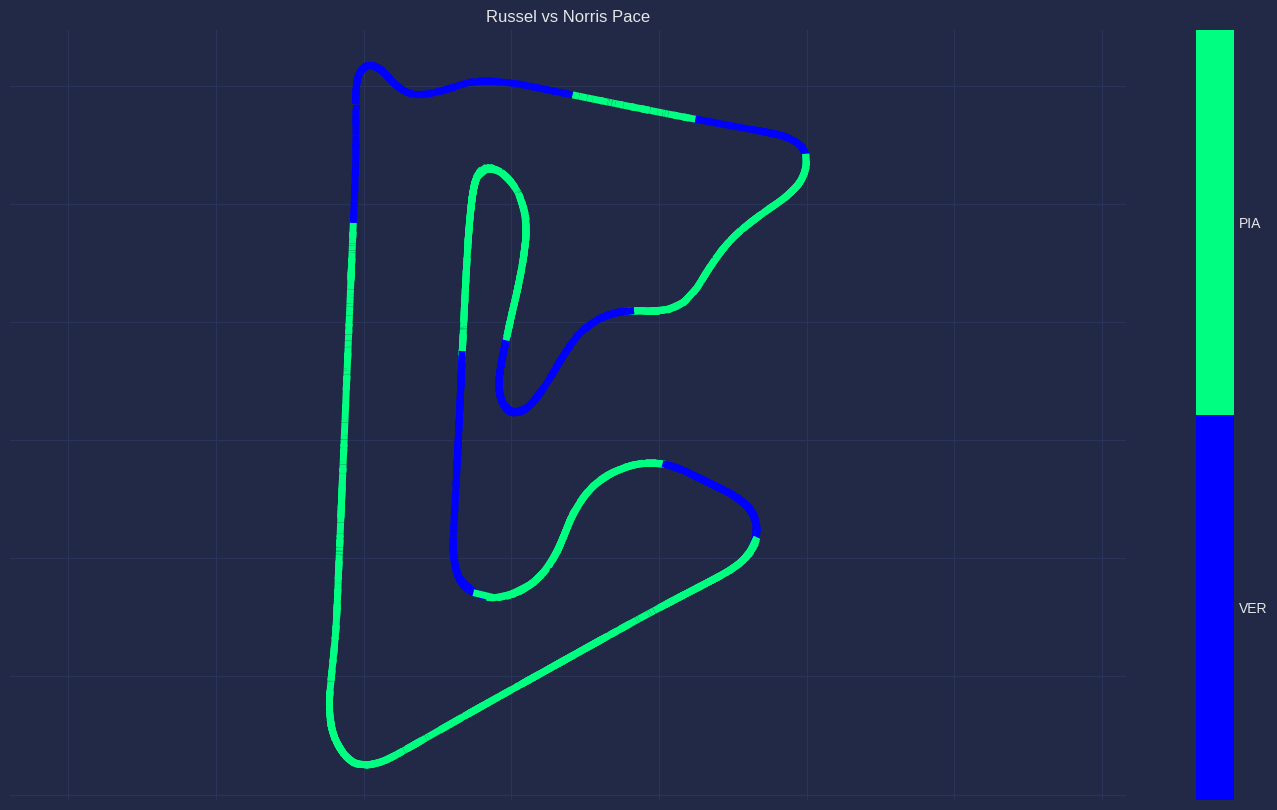

In [35]:
x = np.array(telemetry['X'].values)
y = np.array(telemetry['Y'].values)

points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
fastest_driver_array = telemetry['Fastest_driver_int'].to_numpy().astype(float)

cmap = plt.get_cmap('winter', 2)  # Create a colormap with 2 colors
lc_comp = LineCollection(segments, norm=plt.Normalize(1, cmap.N+1), cmap=cmap)
lc_comp.set_array(fastest_driver_array)
lc_comp.set_linewidth(5)

plt.rcParams['figure.figsize'] = [18, 10]
plt.gca().add_collection(lc_comp)
plt.axis('equal')
plt.tick_params(labelleft=False, left=False, labelbottom=False, bottom=False)

cbar = plt.colorbar(mappable=lc_comp, boundaries=[1, 2, 3])
cbar.set_ticks([1.5, 2.5])
cbar.set_ticklabels(['VER', 'PIA'])
plt.title("Russel vs Norris Pace")
plt.show()
